Setup & Imports (provided starter code)

Part 1: Parameter Analysis Function

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
import seaborn as sns

In [42]:
def sir_model(y, t, beta, gamma):
    """
    SIR model differential equations

    Parameters:
    - y: [S, I, R] populations at time t
    - beta: transmission rate
    - gamma: recovery rate

    Returns:
    - [dS/dt, dI/dt, dR/dt]
    """
    S,I,R=y
    N=S+I+R  # Total population

    # TODO: Implement the three differential equations
    # Hint: Use the mathematical equations from the background

    dSdt= -beta*S*I/N
    dIdt=beta*S*I/N - gamma*I
    dRdt=gamma*I

    return dSdt,dIdt,dRdt

In [43]:
def analyze_recovery_rates(beta,mu,N,I0,simulation_days):
    """
    Analyze epidemic outcomes for different recovery rates.

    Parameters:
    -----------
    beta : float
        Transmission rate
    mu : float  
        Mortality rate
    N : int
        Total population
    I0 : int
        Initial infected individuals
    simulation_days : int
        Simulation duration in days

    Returns:
    --------
    pandas.DataFrame
        Results summary for each recovery rate
    """
    # Your implementation here

    gamma_values=[0.05,0.1,0.15,0.2,0.25]
    S0=N - I0
    R0_initial =0
    D0= 0
    y0 = [S0,I0,R0_initial, D0]
    t = np.linspace(0,simulation_days - 1,simulation_days)
    results=  []
    plt.figure(figsize=(11,  7))
    for gamma in gamma_values:
        sol =odeint(sird_model,y0,t,args=(beta, gamma, mu))
        S,I,R,D = sol.T
        peak_infected = np.max(I)
        peak_day = np.argmax(I)
        total_deaths = D[-1]
        R0 =beta/gamma
        results.append({ 'gamma':gamma, 'R0':R0, 'peak_infected' : peak_infected,'peak_day': peak_day,'total_deaths': total_deaths})
        plt.plot(t, I, linewidth=2, label=f'γ={gamma:.2f} (R₀={R0:.2f})')
    plt.xlabel('Time (days)', fontsize=12)
    plt.ylabel('Number of Infectious Individuals', fontsize=12)
    plt.title('Effect of Recovery Rate on Epidemic Dynamics', fontsize=14)
    plt.legend(title='Recovery Rate')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    results_df = pd.DataFrame(results)
    results_df['R0'] = results_df['R0'].round(2)
    results_df['peak_infected'] = results_df['peak_infected'].round(0).astype(int)
    results_df['total_deaths'] = results_df['total_deaths'].round(0).astype(int)

    return  results_df

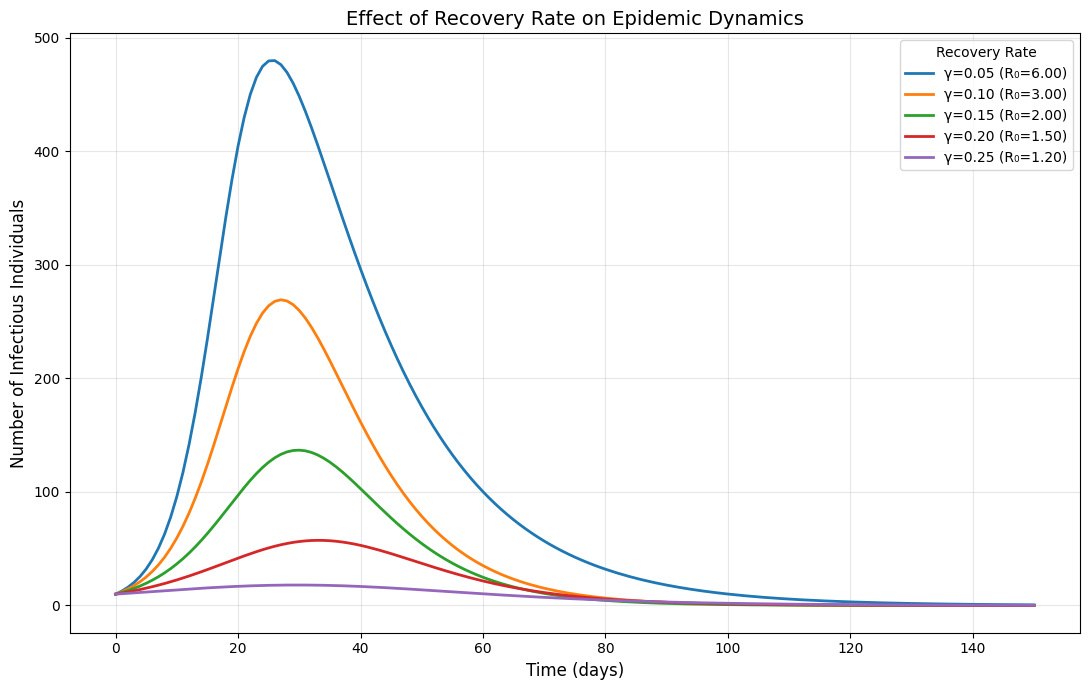

   gamma   R0  peak_infected  peak_day  total_deaths
0   0.05  6.0            480        26           165
1   0.10  3.0            269        27            84
2   0.15  2.0            137        30            48
3   0.20  1.5             57        33            26
4   0.25  1.2             18        30            11


In [44]:
results= analyze_recovery_rates(beta=0.3,mu=0.01,N=1000,I0=10,simulation_days=151)
print (results)

Part 2: Scenario Comparison

Part 3: Policy Recommendations

Conclusions